# MAM 2024 cumulative rainfall — did any model reproduce the Kenya/Tanzania flooding?

**Goal.** Evaluate each ML model's **cumulative rainfall over the MAM 2024 long-rains
season** (1 Mar – 31 May 2024) against three references (CHIRPS, ERA5, TAMSAT), with
the headline question: **did any model reproduce the severe flooding that hit Kenya
and Tanzania?**

**Framing.** Floods are an *extremes-in-time* phenomenon that seasonal totals can
hide, so the analysis evaluates four complementary things:

1. **Anomalies, not just totals** — the flood was an *anomaly*; we compare each
   model's seasonal excess over climatology with the observed excess
   (`model − clim` vs `CHIRPS − clim`), and score the **anomaly pattern correlation**
   (plain spatial correlation of totals is dominated by fixed geography — every
   model scores high just by knowing where it usually rains).
2. **Ensemble range, not just the mean** — the ensemble mean smooths exactly the
   heavy days that matter; cumulative curves carry a 10–90% member band, and member
   P90 totals are tabulated ("did the flooding fall inside the plausible range?").
3. **Extreme indices** — ETCCDI-style Rx1day, **Rx5day** (the canonical flood
   index), days > 20/50 mm, SDII and wet-day frequency, computed **per member** then
   averaged (never on the pre-smoothed ensemble mean).
4. **Skill vs climatology** — climatology is the *baseline*, not a peer model:
   `1 − RMSE_model / RMSE_clim` answers "is the ML worth it?"

**Method — fixed-lead seasonal accumulation.** For a fixed lead *L*, sum the daily
forecast valid on every day of MAM (initialised *L* days earlier). Inits are daily
over all 2024, so each MAM valid day is covered exactly once — and this is
**asserted in code**, not assumed. **Lead 1** is the headline; a sensitivity panel
shows bias growth with lead. NeuralGCM is excluded (zarr-v3 stores, unreadable in
this environment).

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from benchmark_ea import analysis_io, domain
from benchmark_ea.config import BenchmarkConfig
from benchmark_ea.verification.data import load_observations

MODELS       = ['gencast', 'graphcast', 'fourcastnet', 'climatology']
ML_MODELS    = ['gencast', 'graphcast', 'fourcastnet']          # climatology = baseline
MODEL_LABELS = {'gencast':'GenCast','graphcast':'GraphCast','fourcastnet':'FourCastNet','climatology':'Climatology'}
MODEL_COLORS = {'gencast':'#2196F3','graphcast':'#E53935','fourcastnet':'#d4a017','climatology':'#999999'}
REFS      = ['CHIRPS', 'ERA5', 'TAMSAT']
REF_STYLE = {'CHIRPS':('#000000','-'), 'ERA5':('#2E7D32','--'), 'TAMSAT':('#8B4513','-.')}

START, END    = '2024-03-01', '2024-05-31'
N_DAYS        = pd.date_range(START, END).size          # 92
LEADS         = [1, 3, 5, 7]
HEADLINE_LEAD = 1
FLOOD_WINDOW  = ('2024-04-15', '2024-05-05')   # approx. peak Kenya/Tanzania flooding
FOCUS         = ['Kenya', 'Tanzania']
PRED_DIR      = 'data/predictions'
OUTDIR        = 'mam2024_cumulative_outputs'
os.makedirs(OUTDIR, exist_ok=True)

## 1 · Load predictions, references, and region masks

In [2]:
cfg = BenchmarkConfig()
preds = analysis_io.load_predictions(PRED_DIR, MODELS)
chirps_da, era5_da, tamsat_da = load_observations(cfg, START, END, OUTDIR)
refs = {'CHIRPS': chirps_da, 'ERA5': era5_da, 'TAMSAT': tamsat_da}

LAT = preds[MODELS[0]].lat.values
LON = preds[MODELS[0]].lon.values
land  = domain.land_mask(LAT, LON).astype(bool)
cmask = domain.country_masks(LAT, LON)
aw    = domain.area_weights(LAT, LON)

def region_weight(country=None):
    m = land if country is None else (land & cmask[country])
    return aw * m

Loading model predictions …


  gencast          {'init_time': 359, 'sample': 10, 'lead_day': 4, 'lat': 28, 'lon': 25}


  graphcast        {'init_time': 359, 'sample': 1, 'lead_day': 4, 'lat': 28, 'lon': 25}


  fourcastnet      {'init_time': 359, 'sample': 1, 'lead_day': 4, 'lat': 28, 'lon': 25}


  climatology      {'init_time': 359, 'sample': 20, 'lead_day': 4, 'lat': 28, 'lon': 25}

Loading observations …


...

TAMSAT days:  73%|███████▎  | 67/92 [00:00<00:00, 131.39it/s]

TAMSAT days:  88%|████████▊ | 81/92 [00:00<00:00, 131.53it/s]

TAMSAT days: 100%|██████████| 92/92 [00:00<00:00, 129.57it/s]

  Regridding TAMSAT 0.0375° → 1° …


  Cached combined TAMSAT → tamsat_rfe_2024-03-01_2024-05-31_22b0a73317b4.nc
  TAMSAT  {'time': 92, 'lat': 28, 'lon': 25}


## 2 · Helpers
`mam_daily` builds the valid-day-aligned MAM stack and **asserts complete coverage
(92 days, no gaps / double-counting)**. Accumulations use `skipna=False` for models
*and* observations, so a missing day propagates identically on both sides.
`draw_map` centralises the cartopy boilerplate so all maps stay consistent.

In [3]:
def mam_daily(da, lead=None, start=START, end=END):
    '''Daily MAM fields (valid_time, [sample,] lat, lon), valid-day aligned.
    Model: pass lead (forecast init = valid − lead). Reference: lead=None.
    Asserts every day of the season is present exactly once.'''
    if lead is None:
        d = da.sel(time=slice(start, end)).rename({'time': 'valid_time'})
    else:
        d = da.sel(lead_day=lead)
        vt = pd.to_datetime(d.init_time.values) + pd.Timedelta(days=int(lead))
        d = (d.assign_coords(valid_time=('init_time', vt))
               .swap_dims({'init_time': 'valid_time'}).sortby('valid_time')
               .sel(valid_time=slice(start, end)))
    n_expected = pd.date_range(start, end).size
    assert d.valid_time.size == n_expected, (
        f'coverage hole: {d.valid_time.size} valid days, expected {n_expected} '
        f'(lead={lead})')
    assert pd.Index(pd.to_datetime(d.valid_time.values)).is_unique, 'double-counted valid day'
    return d.compute()

def seasonal_accum(da, lead=None):
    '''Ensemble-mean MAM total (lat, lon), mm. skipna=False on BOTH models and obs.'''
    d = mam_daily(da, lead)
    if 'sample' in d.dims:
        d = d.mean('sample')
    return d.sum('valid_time', skipna=False)

def aw_mean(field, country=None):
    '''Area-weighted mean of a (lat,lon) field over land [country], NaN-safe.'''
    w = region_weight(country).where(np.isfinite(field), 0.0)
    return float((field.where(np.isfinite(field), 0.0) * w).sum() / w.sum())

def area_mean_series(daily, country=None):
    '''Area-weighted regional daily-mean series. Keeps members if present:
    returns pd.DataFrame (date × member) for ensembles, pd.Series otherwise.'''
    w  = region_weight(country)
    ww = w.where(np.isfinite(daily), 0.0)
    s  = (daily.where(np.isfinite(daily), 0.0) * ww).sum(['lat', 'lon']) / ww.sum(['lat', 'lon'])
    idx = pd.to_datetime(s.valid_time.values)
    if 'sample' in s.dims:
        return pd.DataFrame(s.transpose('valid_time', 'sample').values, index=idx)
    return pd.Series(s.values, index=idx)

proj   = ccrs.PlateCarree()
extent = [LON.min()-0.5, LON.max()+0.5, LAT.min()-0.5, LAT.max()+0.5]

def draw_map(ax, field, cmap, norm=None, vmin=None, vmax=None):
    '''Shared cartopy panel: extent, ocean, field, coastline, borders.'''
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.OCEAN, facecolor='#dce9f5', zorder=0)
    im = ax.pcolormesh(LON, LAT, np.ma.masked_invalid(np.asarray(field)), cmap=cmap,
                       norm=norm, vmin=vmin, vmax=vmax, transform=proj,
                       shading='nearest', zorder=1)
    ax.add_feature(cfeature.COASTLINE, lw=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, lw=0.4, ls=':', zorder=3)
    return im

## 3 · Seasonal totals, anomalies, and member-resolved daily stacks
Coverage assertions run inside `mam_daily` — a silent missing-init hole would raise
here instead of quietly biasing a total downward.

In [4]:
# Member-resolved daily stacks at the headline lead (reused by curves/indices).
D_model = {m: mam_daily(preds[m], HEADLINE_LEAD) for m in MODELS}
D_ref   = {r: mam_daily(refs[r])                 for r in REFS}

S_model = {m: D_model[m].mean('sample').sum('valid_time', skipna=False).where(land) for m in MODELS}
S_ref   = {r: D_ref[r].sum('valid_time', skipna=False).where(land) for r in REFS}
S_model_leads = {m: {ld: seasonal_accum(preds[m], ld).where(land) for ld in LEADS} for m in MODELS}

# Anomalies relative to the climatology baseline (CHIRPS 2000–2020 day-of-year).
S_clim = S_model['climatology']
A_model = {m: (S_model[m] - S_clim) for m in ML_MODELS}
A_ref   = {r: (S_ref[r]   - S_clim) for r in REFS}

print(f'Coverage OK: {N_DAYS} valid days per model/lead (asserted).')
print('\nDomain-mean MAM total (mm):')
for r in REFS:   print(f'  {r:12s} {aw_mean(S_ref[r]):6.1f}')
for m in MODELS: print(f'  {MODEL_LABELS[m]:12s} {aw_mean(S_model[m]):6.1f}  (lead {HEADLINE_LEAD})')

Coverage OK: 92 valid days per model/lead (asserted).

Domain-mean MAM total (mm):
  CHIRPS        268.3
  ERA5          262.1
  TAMSAT        256.2
  GenCast       241.7  (lead 1)
  GraphCast     238.8  (lead 1)
  FourCastNet   154.4  (lead 1)
  Climatology   248.1  (lead 1)


## 4 · Cumulative rainfall maps — references vs models

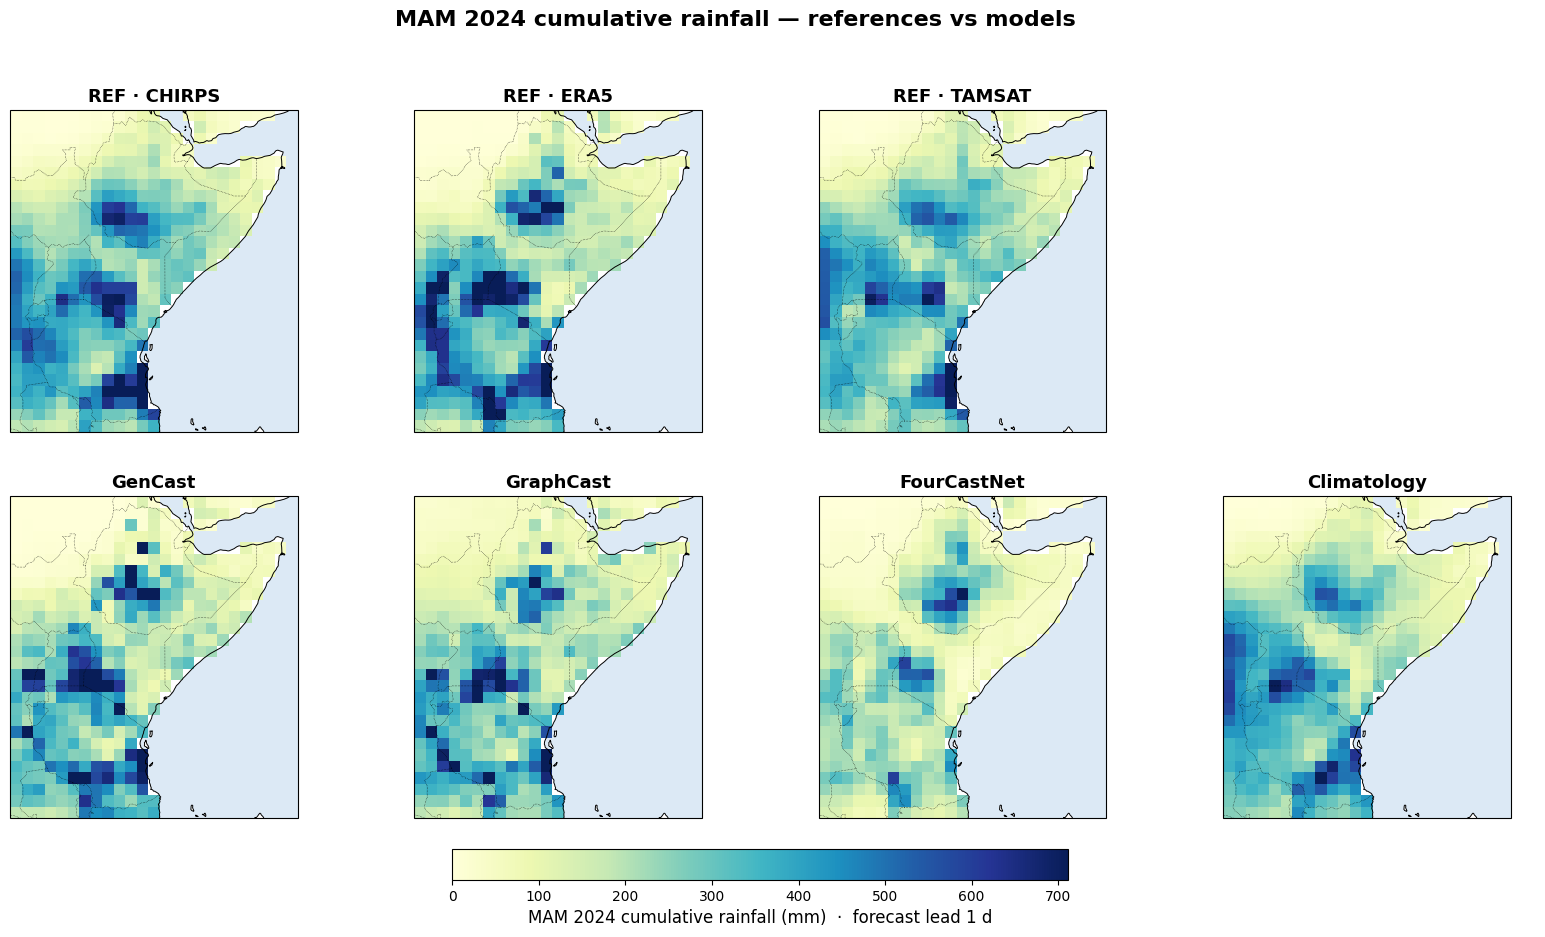

In [5]:
allvals = np.concatenate([S_ref[r].values[np.isfinite(S_ref[r].values)] for r in REFS] +
                         [S_model[m].values[np.isfinite(S_model[m].values)] for m in MODELS])
vmax = np.nanpercentile(allvals, 98)
order = [('ref','CHIRPS'),('ref','ERA5'),('ref','TAMSAT'), None,
         ('model','gencast'),('model','graphcast'),('model','fourcastnet'),('model','climatology')]
fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw={'projection': proj})
im = None
for ax, item in zip(axes.ravel(), order):
    if item is None:
        ax.axis('off'); continue
    kind, key = item
    field = S_ref[key] if kind == 'ref' else S_model[key]
    im = draw_map(ax, field.values, 'YlGnBu', vmin=0, vmax=vmax)
    ax.set_title(('REF · ' + key) if kind == 'ref' else MODEL_LABELS[key],
                 fontsize=13, fontweight='bold')
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.04, pad=0.04, shrink=0.5)
cbar.set_label(f'MAM 2024 cumulative rainfall (mm)  ·  forecast lead {HEADLINE_LEAD} d', fontsize=12)
fig.suptitle('MAM 2024 cumulative rainfall — references vs models', fontsize=16, fontweight='bold', y=0.98)
fig.savefig(f'{OUTDIR}/cumulative_maps.png', dpi=140, bbox_inches='tight')
plt.show()

## 5 · Bias maps — model minus CHIRPS (absolute totals)

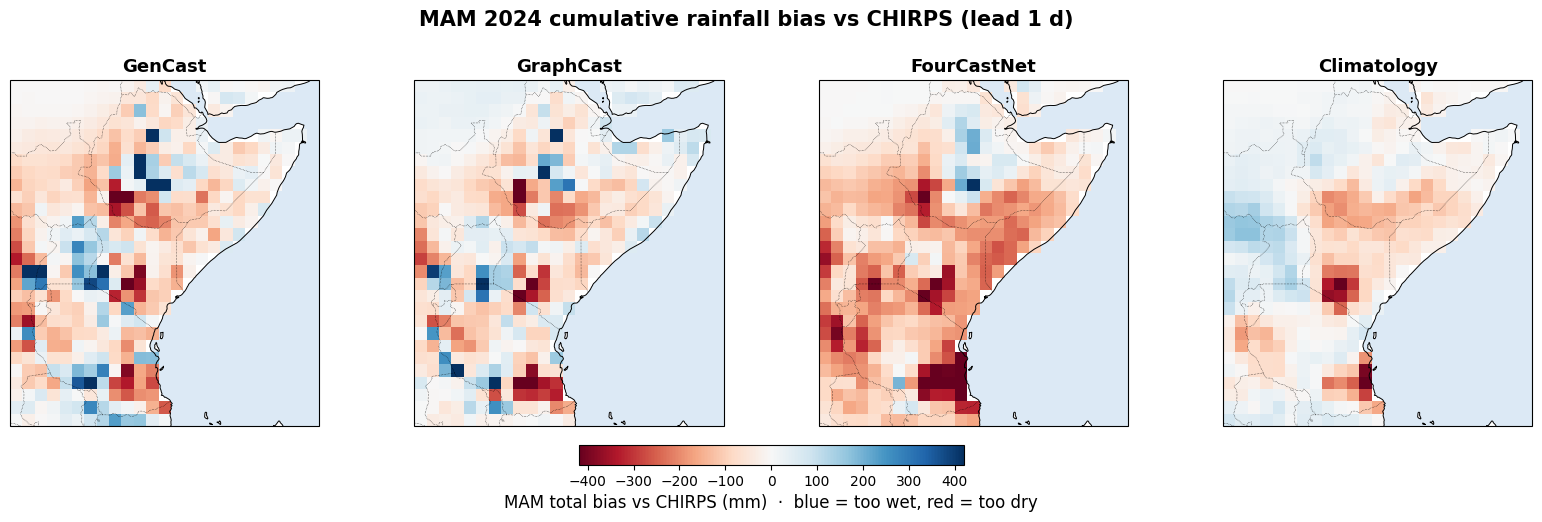

In [6]:
diffs = {m: (S_model[m] - S_ref['CHIRPS']) for m in MODELS}
bmax = np.nanpercentile(np.abs(np.concatenate(
    [diffs[m].values[np.isfinite(diffs[m].values)] for m in MODELS])), 98)
norm = TwoSlopeNorm(vmin=-bmax, vcenter=0, vmax=bmax)
fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': proj})
for ax, m in zip(axes, MODELS):
    im = draw_map(ax, diffs[m].values, 'RdBu', norm=norm)
    ax.set_title(MODEL_LABELS[m], fontsize=13, fontweight='bold')
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05, shrink=0.5)
cbar.set_label('MAM total bias vs CHIRPS (mm)  ·  blue = too wet, red = too dry', fontsize=12)
fig.suptitle(f'MAM 2024 cumulative rainfall bias vs CHIRPS (lead {HEADLINE_LEAD} d)',
             fontsize=15, fontweight='bold', y=1.02)
fig.savefig(f'{OUTDIR}/cumulative_bias_maps.png', dpi=140, bbox_inches='tight')
plt.show()

## 6 · Anomaly maps — the flood as a departure from climatology
Top row: observed MAM anomaly (reference − climatology). Bottom row: each ML
model's predicted anomaly. This is the direct visual answer to "did the model
predict above-normal rain where it was observed?" — the fixed wet/dry geography is
removed.

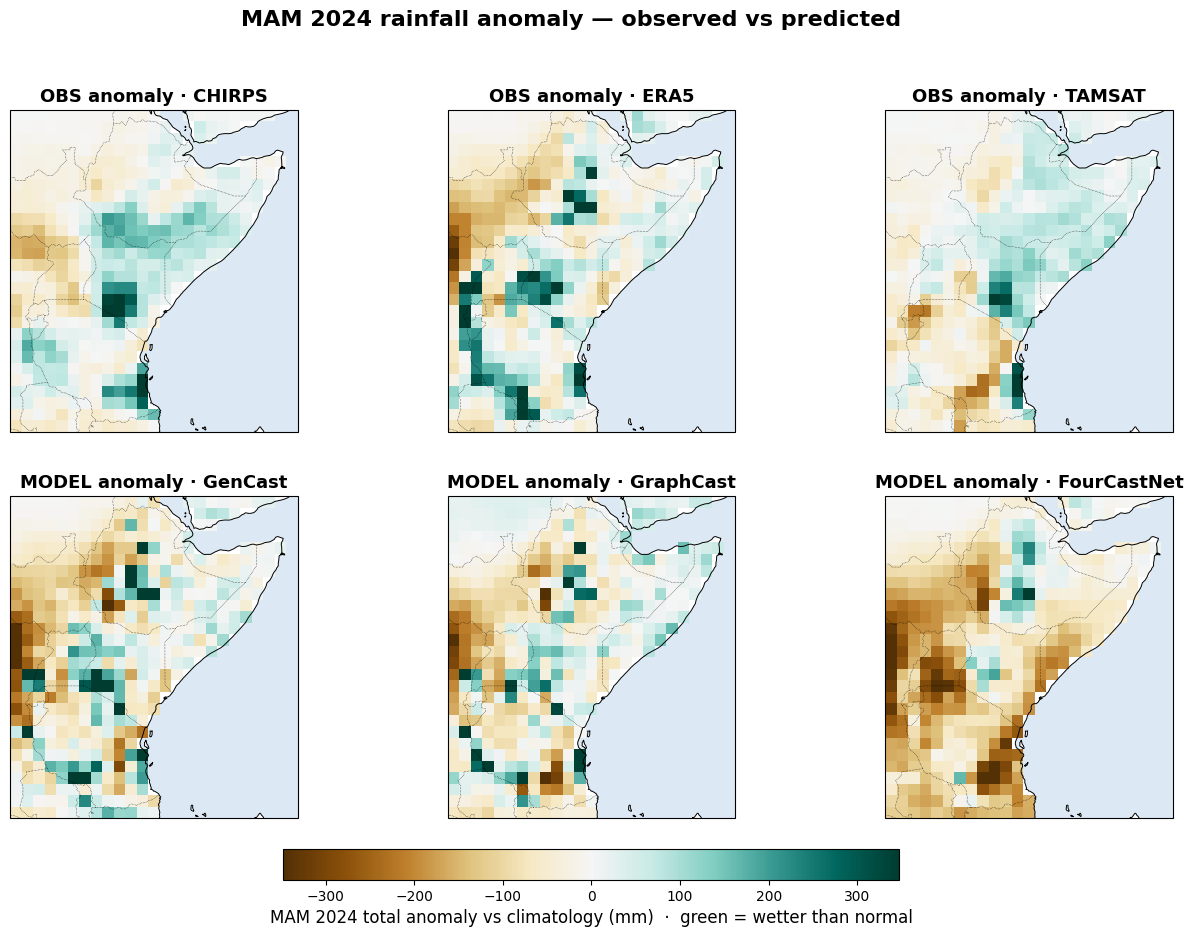

In [7]:
anom_fields = list(A_ref.values()) + list(A_model.values())
amax = np.nanpercentile(np.abs(np.concatenate(
    [f.values[np.isfinite(f.values)] for f in anom_fields])), 98)
anorm = TwoSlopeNorm(vmin=-amax, vcenter=0, vmax=amax)
fig, axes = plt.subplots(2, 3, figsize=(16, 10), subplot_kw={'projection': proj})
for ax, r in zip(axes[0], REFS):
    im = draw_map(ax, A_ref[r].values, 'BrBG', norm=anorm)
    ax.set_title(f'OBS anomaly · {r}', fontsize=13, fontweight='bold')
for ax, m in zip(axes[1], ML_MODELS):
    im = draw_map(ax, A_model[m].values, 'BrBG', norm=anorm)
    ax.set_title(f'MODEL anomaly · {MODEL_LABELS[m]}', fontsize=13, fontweight='bold')
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.04, pad=0.04, shrink=0.5)
cbar.set_label('MAM 2024 total anomaly vs climatology (mm)  ·  green = wetter than normal', fontsize=12)
fig.suptitle('MAM 2024 rainfall anomaly — observed vs predicted', fontsize=16, fontweight='bold', y=0.98)
fig.savefig(f'{OUTDIR}/anomaly_maps.png', dpi=140, bbox_inches='tight')
plt.show()

## 7 · Flood tracking — cumulative curves with ensemble range
Shaded model bands = **10th–90th percentile across ensemble members** (GenCast 10,
Climatology 21); lines = ensemble mean (single member for deterministic models).
The fair flood question is whether the observed accumulation stays **inside** the
ensemble band, not whether the mean matches it.

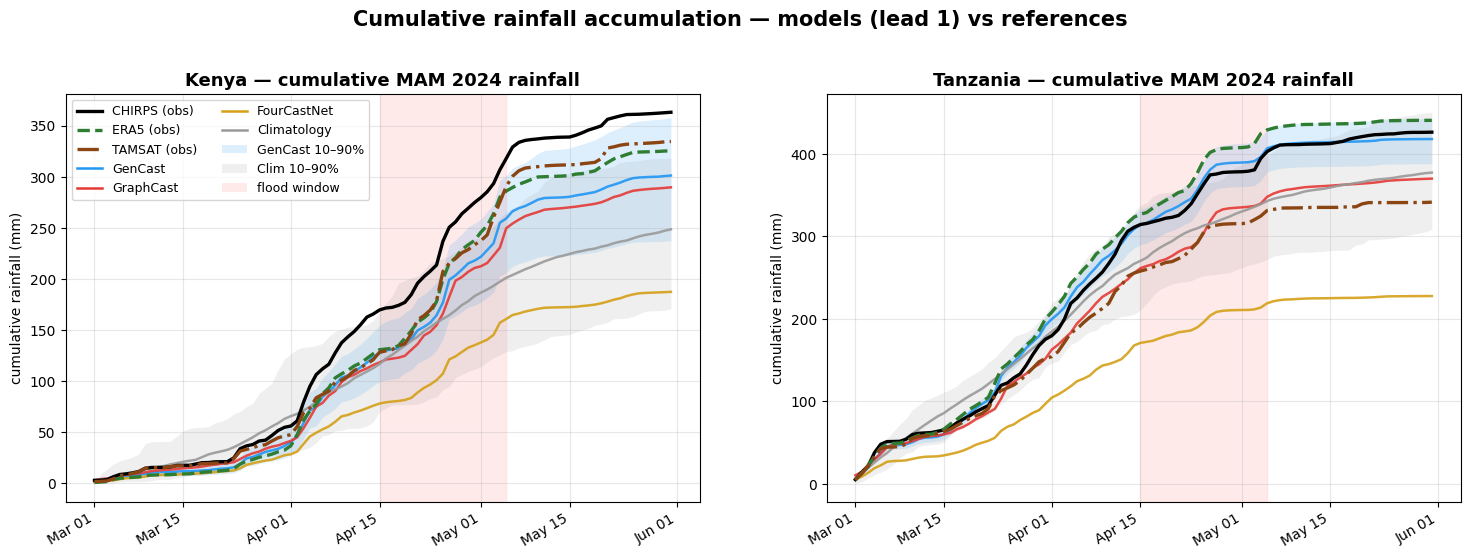

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, country in zip(axes, FOCUS):
    for m in MODELS:
        s = area_mean_series(D_model[m], country)
        if isinstance(s, pd.DataFrame) and s.shape[1] > 1:
            cum = s.cumsum()
            ax.fill_between(cum.index, cum.quantile(0.10, axis=1), cum.quantile(0.90, axis=1),
                            color=MODEL_COLORS[m], alpha=0.15, lw=0, zorder=1)
            ax.plot(cum.index, cum.mean(axis=1), color=MODEL_COLORS[m], lw=1.8,
                    alpha=0.9, zorder=2)
        else:
            s = s if isinstance(s, pd.Series) else s.iloc[:, 0]
            ax.plot(s.index, s.cumsum().values, color=MODEL_COLORS[m], lw=1.8,
                    alpha=0.9, zorder=2)
    for r in REFS:
        s = area_mean_series(D_ref[r], country); c, ls = REF_STYLE[r]
        ax.plot(s.index, s.cumsum().values, color=c, ls=ls, lw=2.4, zorder=5)
    ax.axvspan(pd.Timestamp(FLOOD_WINDOW[0]), pd.Timestamp(FLOOD_WINDOW[1]),
               color='#ffd6d6', alpha=0.5, zorder=0)
    ax.set_title(f'{country} — cumulative MAM 2024 rainfall', fontsize=13, fontweight='bold')
    ax.set_ylabel('cumulative rainfall (mm)'); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
handles = ([Line2D([0],[0], color=REF_STYLE[r][0], ls=REF_STYLE[r][1], lw=2.4, label=f'{r} (obs)') for r in REFS]
           + [Line2D([0],[0], color=MODEL_COLORS[m], lw=1.8, label=MODEL_LABELS[m]) for m in MODELS]
           + [Patch(fc=MODEL_COLORS['gencast'], alpha=0.15, label='GenCast 10–90%'),
              Patch(fc=MODEL_COLORS['climatology'], alpha=0.15, label='Clim 10–90%'),
              Patch(fc='#ffd6d6', alpha=0.5, label='flood window')])
axes[0].legend(handles=handles, ncol=2, fontsize=9, loc='upper left')
fig.suptitle('Cumulative rainfall accumulation — models (lead 1) vs references',
             fontsize=15, fontweight='bold', y=1.02)
fig.autofmt_xdate()
fig.savefig(f'{OUTDIR}/flood_cumulative_curves.png', dpi=140, bbox_inches='tight')
plt.show()

## 7b · Subregional wet/dry map — cumulative rainfall as % of the domain total
The domain is split into a **3×3 grid of tiles** (land only; near-empty ocean tiles dropped). Each panel is placed geographically (north at top) and mirrors the cumulative-curve figure above, but the **shared y-axis is each tile's cumulative area-weighted rainfall as a % of the CHIRPS domain-mean seasonal total**.

Read it as: a curve ending **near/above 100 %** = a **wet** tile (≥ the domain-average season); a curve flattening **low** = a **dry** tile. Because every source is normalised by the *same* CHIRPS domain total, a globally-too-dry model sits low everywhere, and a model with the wrong spatial pattern is high in the wrong tiles — so both overall bias and *where* the wet/dry pattern sits are visible at once.


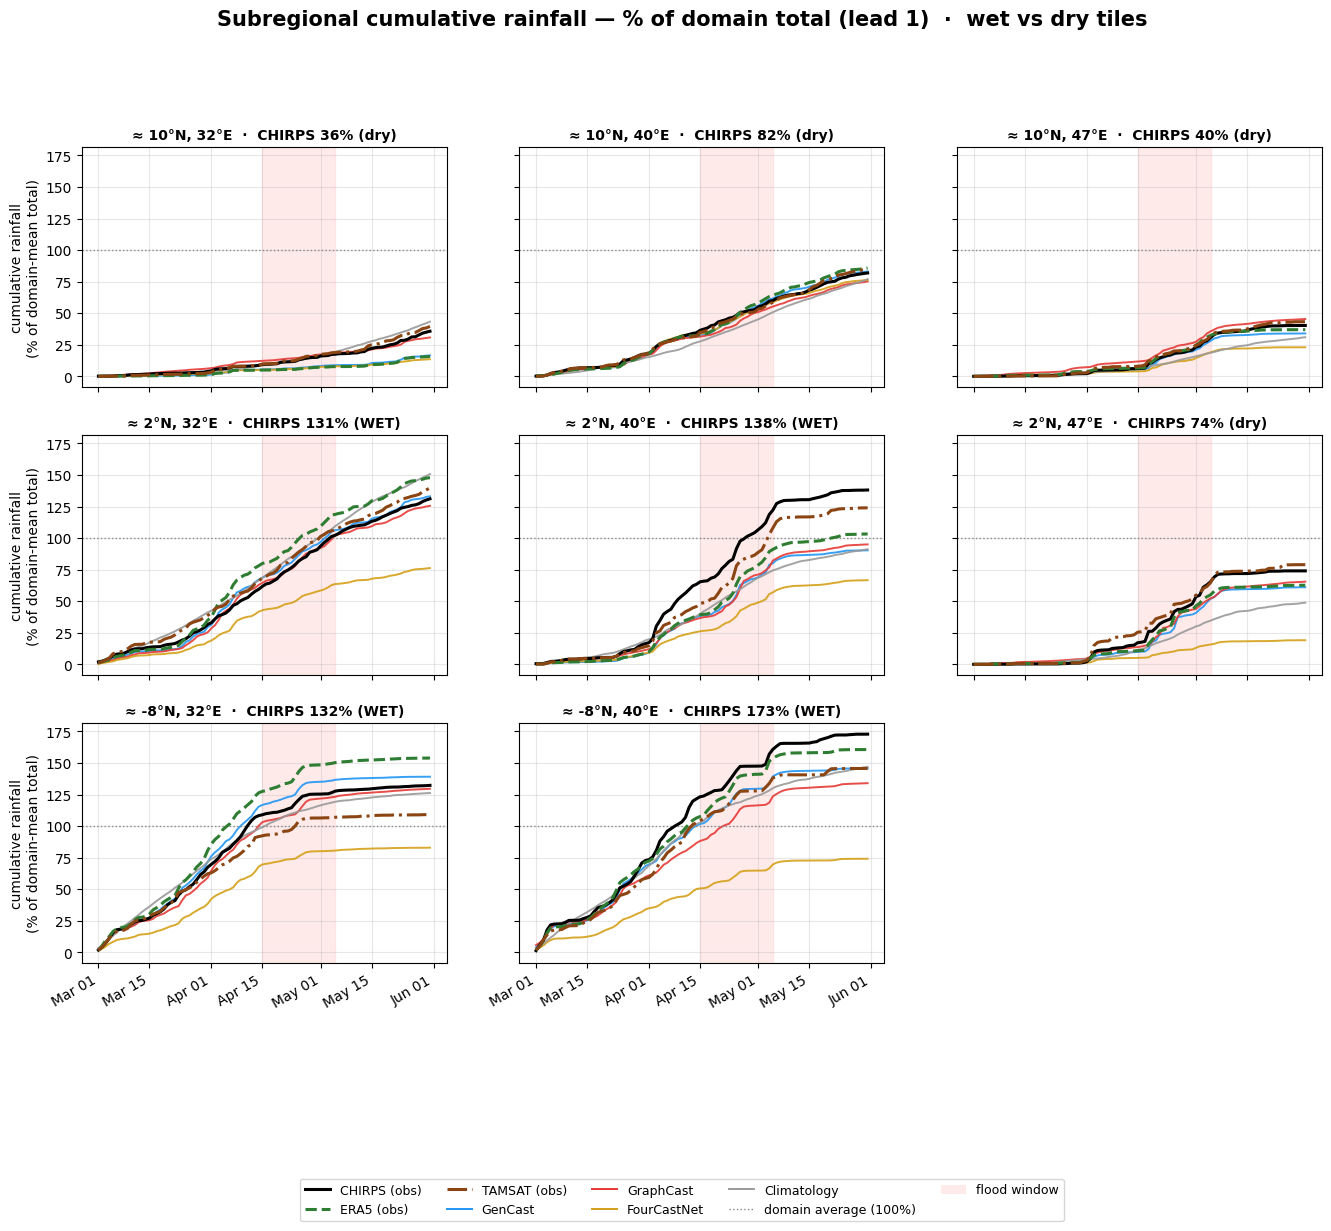

In [9]:
# --- 3x3 land tiles over the domain, north at top -------------------------------
landvals = land.values
lat_has, lon_has = landvals.any(axis=1), landvals.any(axis=0)
lat_lo, lat_hi = LAT[lat_has].min(), LAT[lat_has].max()
lon_lo, lon_hi = LON[lon_has].min(), LON[lon_has].max()
lat_edges = np.linspace(lat_lo, lat_hi, 4)
lon_edges = np.linspace(lon_lo, lon_hi, 4)
eps = 1e-6
MIN_TILE_CELLS = 5                       # drop tiles with too little land

def tile_mask(la0, la1, lo0, lo1):
    return (land & (land.lat >= la0 - eps) & (land.lat <= la1 + eps)
                 & (land.lon >= lo0 - eps) & (land.lon <= lo1 + eps))

# denominator: CHIRPS domain-mean MAM total (mm)
DOM_TOTAL = aw_mean(S_ref['CHIRPS'])

def tile_cum_pct(daily, m):
    '''Cumulative area-weighted tile rainfall as % of the CHIRPS domain total.'''
    d = daily.mean('sample') if 'sample' in daily.dims else daily
    w  = (aw * m).where(np.isfinite(d), 0.0)
    s  = (d.where(np.isfinite(d), 0.0) * w).sum(['lat', 'lon']) / w.sum(['lat', 'lon'])
    idx = pd.to_datetime(s.valid_time.values)
    return pd.Series(100.0 * np.cumsum(s.values) / DOM_TOTAL, index=idx)

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)
for r in range(3):                        # row 0 = northernmost band
    la0, la1 = lat_edges[2 - r], lat_edges[3 - r]
    for c in range(3):
        ax = axes[r, c]
        lo0, lo1 = lon_edges[c], lon_edges[c + 1]
        m = tile_mask(la0, la1, lo0, lo1)
        if int(m.sum()) < MIN_TILE_CELLS:
            ax.axis('off'); continue
        for ref in REFS:
            col, ls = REF_STYLE[ref]
            s = tile_cum_pct(D_ref[ref], m)
            ax.plot(s.index, s.values, color=col, ls=ls, lw=2.2, zorder=5)
        chirps_final = tile_cum_pct(D_ref['CHIRPS'], m).iloc[-1]
        for mdl in MODELS:
            s = tile_cum_pct(D_model[mdl], m)
            ax.plot(s.index, s.values, color=MODEL_COLORS[mdl], lw=1.4, alpha=0.9)
        ax.axvspan(pd.Timestamp(FLOOD_WINDOW[0]), pd.Timestamp(FLOOD_WINDOW[1]),
                   color='#ffd6d6', alpha=0.5, zorder=0)
        ax.axhline(100, color='#888', ls=':', lw=1)          # domain-average line
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        tag = 'WET' if chirps_final >= 100 else 'dry'
        ax.set_title(f'≈ {(la0 + la1) / 2:.0f}°N, {(lo0 + lo1) / 2:.0f}°E'
                     f'  ·  CHIRPS {chirps_final:.0f}% ({tag})',
                     fontsize=10, fontweight='bold')
        if c == 0:
            ax.set_ylabel('cumulative rainfall\n(% of domain-mean total)')

handles = ([Line2D([0], [0], color=REF_STYLE[r][0], ls=REF_STYLE[r][1], lw=2.2,
                   label=f'{r} (obs)') for r in REFS]
           + [Line2D([0], [0], color=MODEL_COLORS[m], lw=1.4, label=MODEL_LABELS[m])
              for m in MODELS]
           + [Line2D([0], [0], color='#888', ls=':', lw=1, label='domain average (100%)'),
              Patch(fc='#ffd6d6', alpha=0.5, label='flood window')])
fig.legend(handles=handles, ncol=5, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Subregional cumulative rainfall — % of domain total (lead 1)  ·  '
             'wet vs dry tiles', fontsize=15, fontweight='bold', y=0.995)
fig.autofmt_xdate()
fig.savefig(f'{OUTDIR}/subregional_cumulative_pct.png', dpi=140, bbox_inches='tight')
plt.show()


## 8 · Daily rainfall with flood-window zoom
Left: full season. Right: zoom on the flood window, with the **observed (CHIRPS)
peak-rain day marked** — does the model peak align in *time*, not just magnitude?

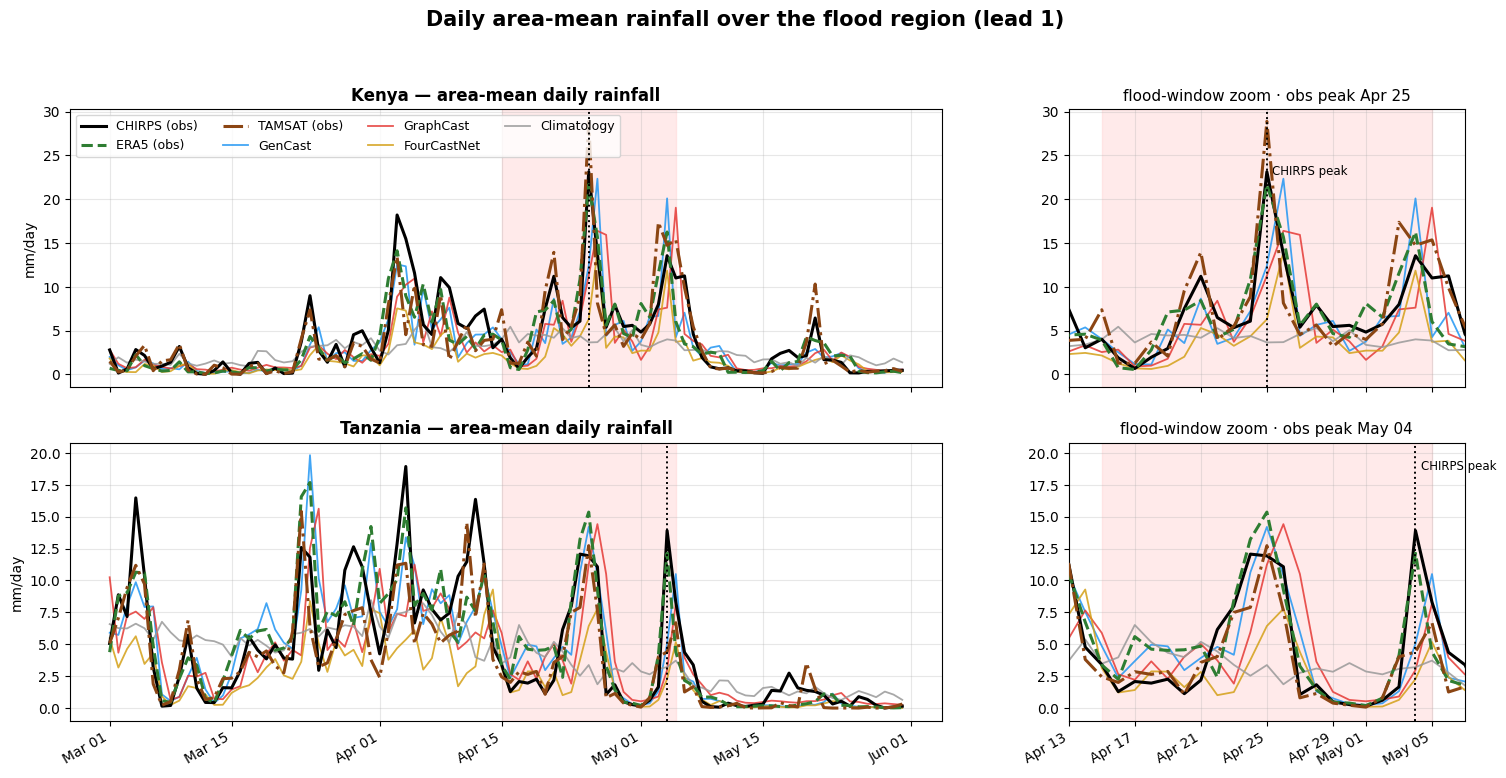

In [10]:
fig, axes = plt.subplots(len(FOCUS), 2, figsize=(18, 4.5 * len(FOCUS)),
                         gridspec_kw={'width_ratios': [2.2, 1]})
for row, country in enumerate(FOCUS):
    obs_s = {r: area_mean_series(D_ref[r], country) for r in REFS}
    mdl_s = {}
    for m in MODELS:
        s = area_mean_series(D_model[m], country)
        mdl_s[m] = s.mean(axis=1) if isinstance(s, pd.DataFrame) else s
    peak = obs_s['CHIRPS'].loc[FLOOD_WINDOW[0]:FLOOD_WINDOW[1]].idxmax()
    for col in range(2):
        ax = axes[row, col]
        for r in REFS:
            c, ls = REF_STYLE[r]
            ax.plot(obs_s[r].index, obs_s[r].values, color=c, ls=ls, lw=2.2,
                    label=f'{r} (obs)', zorder=5)
        for m in MODELS:
            ax.plot(mdl_s[m].index, mdl_s[m].values, color=MODEL_COLORS[m], lw=1.3,
                    alpha=0.85, label=MODEL_LABELS[m])
        ax.axvspan(pd.Timestamp(FLOOD_WINDOW[0]), pd.Timestamp(FLOOD_WINDOW[1]),
                   color='#ffd6d6', alpha=0.5, zorder=0)
        ax.axvline(peak, color='k', ls=':', lw=1.4, zorder=6)
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        if col == 0:
            ax.set_title(f'{country} — area-mean daily rainfall', fontsize=12, fontweight='bold')
            ax.set_ylabel('mm/day')
        else:
            pad = pd.Timedelta(days=2)
            ax.set_xlim(pd.Timestamp(FLOOD_WINDOW[0]) - pad, pd.Timestamp(FLOOD_WINDOW[1]) + pad)
            ax.set_title(f'flood-window zoom · obs peak {peak:%b %d}', fontsize=11)
            ax.annotate('CHIRPS peak', xy=(peak, obs_s['CHIRPS'].max()),
                        xytext=(4, -2), textcoords='offset points', fontsize=8.5)
axes[0, 0].legend(ncol=4, fontsize=9, loc='upper left')
fig.suptitle('Daily area-mean rainfall over the flood region (lead 1)',
             fontsize=15, fontweight='bold', y=0.99)
fig.autofmt_xdate()
fig.savefig(f'{OUTDIR}/flood_daily_series.png', dpi=140, bbox_inches='tight')
plt.show()

## 9 · Summary — MAM totals per region (with ensemble P90)
`P90 members` = 90th percentile of per-member seasonal totals — an ensemble's
plausible wet end. Bias cells are shaded (red = too dry); the best model per
region is bold.

In [11]:
def member_totals(m, country):
    d = D_model[m]
    tot = d.sum('valid_time', skipna=False).where(land)
    if 'sample' not in tot.dims:
        return np.array([aw_mean(tot, country)])
    return np.array([aw_mean(tot.isel(sample=i), country) for i in range(tot.sizes['sample'])])

rows = []
for country in FOCUS + [None]:
    label = 'Domain' if country is None else country
    ref_tot = {r: aw_mean(S_ref[r], country) for r in REFS}
    for r in REFS:
        rows.append({'region': label, 'source': f'{r} (obs)',
                     'MAM total (mm)': ref_tot[r], 'P90 members (mm)': np.nan,
                     'bias vs CHIRPS (mm)': ref_tot[r]-ref_tot['CHIRPS'],
                     'bias vs CHIRPS (%)': 100*(ref_tot[r]-ref_tot['CHIRPS'])/ref_tot['CHIRPS']})
    for m in MODELS:
        mts = member_totals(m, country)
        mt  = aw_mean(S_model[m], country)
        rows.append({'region': label, 'source': MODEL_LABELS[m],
                     'MAM total (mm)': mt,
                     'P90 members (mm)': float(np.percentile(mts, 90)) if len(mts) > 1 else np.nan,
                     'bias vs CHIRPS (mm)': mt-ref_tot['CHIRPS'],
                     'bias vs CHIRPS (%)': 100*(mt-ref_tot['CHIRPS'])/ref_tot['CHIRPS']})
summary = pd.DataFrame(rows).round(1)
summary.to_csv(f'{OUTDIR}/mam_totals_summary.csv', index=False)

def _bold_best(df):
    sty = pd.DataFrame('', index=df.index, columns=df.columns)
    is_model = ~df['source'].str.contains('obs')
    for region in df['region'].unique():
        sub = df[(df['region'] == region) & is_model]
        best = sub['bias vs CHIRPS (%)'].abs().idxmin()
        sty.loc[best, :] = 'font-weight: bold'
    return sty

styled = (summary.style.apply(_bold_best, axis=None)
          .background_gradient(cmap='RdBu', subset=['bias vs CHIRPS (%)'], vmin=-60, vmax=60)
          .format(precision=1, na_rep='—'))
_ = styled.to_html()   # render check
styled

,region,source,MAM total (mm),P90 members (mm),bias vs CHIRPS (mm),bias vs CHIRPS (%)
0,Kenya,CHIRPS (obs),363.2,—,0.0,0.0
1,Kenya,ERA5 (obs),325.4,—,-37.8,-10.4
2,Kenya,TAMSAT (obs),334.5,—,-28.6,-7.9
3,Kenya,GenCast,301.2,358.2,-62.0,-17.1
4,Kenya,GraphCast,289.6,—,-73.5,-20.2
5,Kenya,FourCastNet,187.3,—,-175.8,-48.4
6,Kenya,Climatology,248.5,318.2,-114.6,-31.6
7,Tanzania,CHIRPS (obs),426.2,—,0.0,0.0
8,Tanzania,ERA5 (obs),440.5,—,14.3,3.4
9,Tanzania,TAMSAT (obs),341.3,—,-84.8,-19.9


## 10 · Skill of the seasonal totals — anomaly correlation & skill vs climatology
`anom corr` correlates the **anomaly fields** (`model − clim` vs `ref − clim`),
which isolates whether the model captured the 2024-specific excess — plain
correlation of totals is inflated by fixed geography (climatology itself scores
~0.86 domain-wide by construction). `skill vs clim` = `1 − RMSE_model / RMSE_clim`
(> 0 ⇒ the ML model beats the climatological baseline).

In [12]:
def spatial_scores(model_field, ref_field, country=None):
    m = land if country is None else (land & cmask[country])
    mv = model_field.values[m.values]; rv = ref_field.values[m.values]
    ok = np.isfinite(mv) & np.isfinite(rv); mv, rv = mv[ok], rv[ok]
    bias = float(np.mean(mv - rv))
    rmse = float(np.sqrt(np.mean((mv - rv) ** 2)))
    corr = (float(np.corrcoef(mv, rv)[0, 1])
            if len(mv) > 2 and np.std(mv) > 0 and np.std(rv) > 0 else np.nan)
    return bias, rmse, corr

rows = []
for country in [None] + FOCUS:
    label = 'Domain' if country is None else country
    for r in REFS:
        _, rmse_clim, _ = spatial_scores(S_clim, S_ref[r], country)
        for m in MODELS:
            b, rm, raw_corr = spatial_scores(S_model[m], S_ref[r], country)
            _, _, anom_corr = spatial_scores(S_model[m] - S_clim, S_ref[r] - S_clim, country)
            rows.append({'region': label, 'model': MODEL_LABELS[m], 'ref': r,
                         'bias (mm)': round(b, 1), 'RMSE (mm)': round(rm, 1),
                         'raw corr': round(raw_corr, 3),
                         'anom corr': (np.nan if m == 'climatology' else round(anom_corr, 3)),
                         'skill vs clim': (0.0 if m == 'climatology'
                                           else round(1.0 - rm / rmse_clim, 3))})
skill = pd.DataFrame(rows)
skill.to_csv(f'{OUTDIR}/mam_cumulative_skill.csv', index=False)
print('Headline (vs CHIRPS). anom corr = flood-anomaly pattern skill;')
print('skill vs clim > 0 = beats the climatological baseline on RMSE.\n')
skill[skill.ref == 'CHIRPS'].pivot(index='model', columns='region',
                                   values=['bias (mm)', 'RMSE (mm)', 'anom corr', 'skill vs clim'])

Headline (vs CHIRPS). anom corr = flood-anomaly pattern skill;
skill vs clim > 0 = beats the climatological baseline on RMSE.



bias (mm)                 RMSE (mm)                 anom corr  \
region         Domain  Kenya Tanzania    Domain  Kenya Tanzania    Domain   
model                                                                       
Climatology     -20.0 -114.6    -49.1      90.9  169.4    113.4       NaN   
FourCastNet    -113.3 -175.8   -198.8     171.3  214.7    256.1     0.189   
GenCast         -26.5  -62.0     -8.2     186.8  192.7    309.0     0.198   
GraphCast       -29.2  -73.5    -56.4     134.2  169.1    198.0     0.247   

                            skill vs clim                  
region       Kenya Tanzania        Domain  Kenya Tanzania  
model                                                      
Climatology    NaN      NaN         0.000  0.000    0.000  
FourCastNet  0.404   -0.245        -0.885 -0.267   -1.258  
GenCast      0.099    0.090        -1.056 -0.137   -1.724  
GraphCast   -0.062    0.085        -0.477  0.002   -0.746

## 11 · Extreme / flood indices — was the rain *concentrated* right?
A model can match the seasonal total yet miss the temporal concentration that
floods. ETCCDI-style indices over MAM, area-averaged over each country; for
ensembles each index is computed **per member first**, then averaged (computing on
the ensemble mean would smooth the extremes away).

| index | meaning |
|---|---|
| Rx1day | max 1-day rainfall (mm) |
| **Rx5day** | max 5-day accumulation (mm) — canonical flood index |
| R20mm / R50mm | days with > 20 / > 50 mm |
| SDII | mean intensity on wet days (mm/day) |
| wet-day freq | fraction of days ≥ 1 mm |

In [13]:
def extreme_indices(daily, country):
    w = region_weight(country)
    def reg(field):
        ww = w.where(np.isfinite(field), 0.0)
        return float((field.where(np.isfinite(field), 0.0) * ww).sum(['lat','lon']) / ww.sum(['lat','lon']))
    wet = daily >= 1.0
    idx = {
        'Rx1day (mm)':   daily.max('valid_time'),
        'Rx5day (mm)':   daily.rolling(valid_time=5).sum().max('valid_time'),
        'R20mm (days)':  (daily > 20).sum('valid_time'),
        'R50mm (days)':  (daily > 50).sum('valid_time'),
        'SDII (mm/d)':   daily.where(wet).mean('valid_time'),
        'wet-day freq':  wet.mean('valid_time'),
    }
    out = {}
    for name, f in idx.items():
        if 'sample' in f.dims:
            f = f.mean('sample')          # per-member index, then ensemble mean
        out[name] = reg(f.where(land))
    return out

rows = []
for country in FOCUS:
    for r in REFS:
        rows.append({'region': country, 'source': f'{r} (obs)', **extreme_indices(D_ref[r], country)})
    for m in MODELS:
        rows.append({'region': country, 'source': MODEL_LABELS[m], **extreme_indices(D_model[m], country)})
extremes = pd.DataFrame(rows).round(2)
extremes.to_csv(f'{OUTDIR}/extreme_indices.csv', index=False)
extremes.set_index(['region', 'source'])

Rx1day (mm)  Rx5day (mm)  R20mm (days)  R50mm (days)  \
region   source                                                               
Kenya    CHIRPS (obs)        39.62        87.78          4.42          0.33   
         ERA5 (obs)          33.35        81.18          3.54          0.19   
         TAMSAT (obs)        36.04        76.50          3.50          0.29   
         GenCast             33.23        69.10          3.53          0.38   
         GraphCast           31.30        67.35          2.38          0.10   
         FourCastNet         16.50        39.23          0.77          0.00   
         Climatology         32.82        68.69          2.54          0.15   
Tanzania CHIRPS (obs)        36.71        84.00          4.59          0.36   
         ERA5 (obs)          38.44        92.44          3.70          0.33   
         TAMSAT (obs)        31.87        67.37          3.40          0.20   
         GenCast             36.98        87.95          4.07          0.49   
         GraphCast           33.70        78.42          3.17          0.16   
         FourCastNet         18.82        45.42          0.37          0.03   
         Climatology         40.33        89.00          3.97          0.32   

                       SDII (mm/d)  wet-day freq  
region   source                                   
Kenya    CHIRPS (obs)         9.31          0.42  
         ERA5 (obs)           7.62          0.41  
         TAMSAT (obs)         9.00          0.41  
         GenCast              7.55          0.37  
         GraphCast            5.78          0.47  
         FourCastNet          4.38          0.37  
         Climatology          8.24          0.31  
Tanzania CHIRPS (obs)         9.22          0.48  
         ERA5 (obs)           8.25          0.55  
         TAMSAT (obs)         8.43          0.42  
         GenCast              8.07          0.49  
         GraphCast            6.53          0.56  
         FourCastNet          4.64          0.50  
         Climatology          8.94          0.45

## 12 · Lead-time sensitivity — seasonal-total bias vs forecast lead

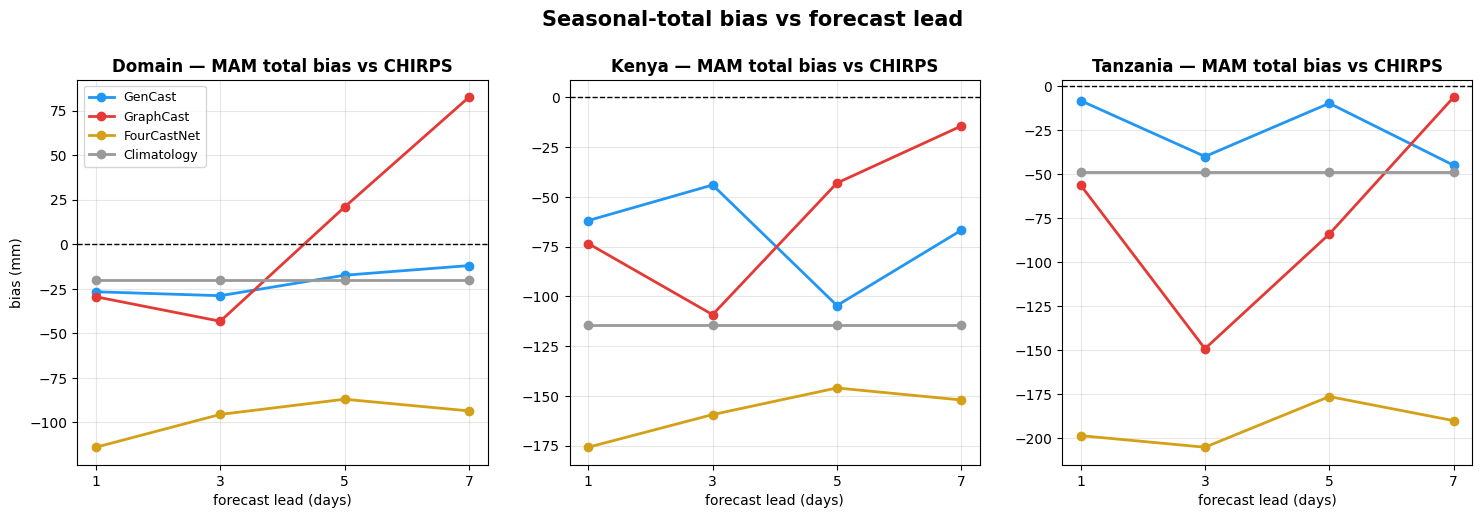

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, country in zip(axes, [None] + FOCUS):
    label = 'Domain' if country is None else country
    chirps_tot = aw_mean(S_ref['CHIRPS'], country)
    for m in MODELS:
        biases = [aw_mean(S_model_leads[m][ld], country) - chirps_tot for ld in LEADS]
        ax.plot(LEADS, biases, 'o-', color=MODEL_COLORS[m], lw=2, label=MODEL_LABELS[m])
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_title(f'{label} — MAM total bias vs CHIRPS', fontsize=12, fontweight='bold')
    ax.set_xlabel('forecast lead (days)'); ax.set_xticks(LEADS); ax.grid(alpha=0.3)
    if country is None:
        ax.set_ylabel('bias (mm)')
axes[0].legend(fontsize=9)
fig.suptitle('Seasonal-total bias vs forecast lead', fontsize=15, fontweight='bold', y=1.02)
fig.savefig(f'{OUTDIR}/lead_sensitivity.png', dpi=140, bbox_inches='tight')
plt.show()

## 13 · How to read this / caveats

**Did a model reproduce the flooding?** Require all four together:
1. **Anomaly pattern** (cell 6 maps, cell 10 `anom corr`) — above-normal rain in the
   right places, with geography factored out;
2. **Plausible range** (cell 7) — observed accumulation inside the ensemble
   10–90% band through the April flood window, and P90 totals (cell 9) reaching the
   observed total;
3. **Temporal concentration** (cells 8, 11) — the daily peak near the observed
   CHIRPS peak date, and Rx5day / R20mm comparable to observed;
4. **Beats climatology** (cell 10 `skill vs clim` > 0) — otherwise a day-of-year
   climatology would have "predicted the flood" equally well.

**Caveats.** Fixed-lead accumulation, lead-1 headline; CHIRPS is the primary truth
(ERA5/TAMSAT shown as the observational spread). Coverage (92 valid days per lead)
is asserted in code, and NaN days propagate identically for models and obs
(`skipna=False` on both). Extreme indices are computed per member, not on the
smoothed ensemble mean; deterministic models (GraphCast, FourCastNet) still
contribute only a single member, so their extremes are read at face value. The
flood window is approximate — adjust `FLOOD_WINDOW`. NeuralGCM is excluded
(zarr-v3 stores; coarse ~2.8° in any case). Anomalies use the CHIRPS 2000–2020
day-of-year climatology (the 21-member baseline's seasonal total), so the anomaly
comparison is most native to the CHIRPS reference.